# 3. Modeling

This notebook trains and evaluates machine-learning models for fake-news classification using the preprocessing strategy defined previously.

The workflow includes:
- loading and preparing the dataset;
- applying the reusable text-cleaning function;
- creating a stratified train-test split;
- combining TF-IDF vectorization and classification inside a scikit-learn pipeline;
- evaluating model performance using cross-validation and a final held-out test set.

## 3.1 Imports

In [1]:
import pandas as pd
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
sys.path.append(str(Path("..").resolve()))

from src.preprocessing import clean_text

## 3.2 Data Preparation

In [4]:
fake_df = pd.read_csv("../data/raw/Fake.csv")
true_df = pd.read_csv("../data/raw/True.csv")

fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[df["text"].str.strip() != ""].reset_index(drop=True)

df = (
    df.drop_duplicates(subset=["text"])
      .reset_index(drop=True)
)

In [6]:
df["clean_text"] = df["text"].apply(clean_text)

df = (
    df[df["clean_text"] != ""]
    .reset_index(drop=True)
)

In [7]:
print("Dataset shape:", df.shape)
print("Duplicate texts:", df.duplicated(subset=["text"]).sum())
print("Empty clean texts:", (df["clean_text"] == "").sum())

Dataset shape: (38591, 6)
Duplicate texts: 0
Empty clean texts: 0


## 3.3 Train-Test Split

In [8]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

## 3.4 Model Comparison

Several classification algorithms are compared to determine which model is best suited to the TF-IDF representation of the news articles.

The following models are evaluated:

- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Multinomial Naive Bayes
- Decision Tree
- Random Forest

Models are evaluated using accuracy, precision, recall, F1-score, and macro F1-score.

Because the class distribution is slightly imbalanced, macro F1-score is particularly useful as it gives equal importance to the Fake and Real classes.

In [15]:
from sklearn.model_selection import cross_validate
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Linear SVM": LinearSVC(),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=30,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    )
}

In [18]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f1_macro": "f1_macro"
}

In [19]:
model_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(min_df=5)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    model_results[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "f1_macro": scores["test_f1_macro"].mean()
    }

    print(name)
    print(f"Accuracy : {model_results[name]['accuracy']:.4f}")
    print(f"Precision: {model_results[name]['precision']:.4f}")
    print(f"Recall   : {model_results[name]['recall']:.4f}")
    print(f"F1-score : {model_results[name]['f1']:.4f}")
    print(f"F1-macro : {model_results[name]['f1_macro']:.4f}")
    print("-" * 40)

Logistic Regression
Accuracy : 0.9792
Precision: 0.9757
Recall   : 0.9867
F1-score : 0.9811
F1-macro : 0.9789
----------------------------------------
Linear SVM
Accuracy : 0.9865
Precision: 0.9842
Recall   : 0.9914
F1-score : 0.9878
F1-macro : 0.9864
----------------------------------------
Multinomial Naive Bayes
Accuracy : 0.9350
Precision: 0.9353
Recall   : 0.9471
F1-score : 0.9412
F1-macro : 0.9343
----------------------------------------
Decision Tree
Accuracy : 0.9300
Precision: 0.9314
Recall   : 0.9418
F1-score : 0.9366
F1-macro : 0.9292
----------------------------------------
Random Forest
Accuracy : 0.9694
Precision: 0.9659
Recall   : 0.9788
F1-score : 0.9723
F1-macro : 0.9690
----------------------------------------


### Model Comparison Results

Linear SVM achieved the strongest overall performance, with an accuracy of approximately **98.65%** and a macro F1-score of approximately **98.64%**.

Logistic Regression also performed strongly, while Random Forest achieved slightly lower performance. Multinomial Naive Bayes and Decision Tree showed substantially lower scores.

Based on these results, Linear SVM was selected for further optimization.

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=5)),
    ("model", LinearSVC())
])

In [22]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

## 3.5 Linear SVM Hyperparameter Tuning

The regularization parameter `C` of the selected Linear SVM is tuned using 5-fold cross-validation.

The following values are evaluated:

- 0.01
- 0.1
- 1
- 10

The optimization criterion is the macro F1-score.

The TF-IDF vectorizer remains inside the pipeline so that, within each cross-validation fold, the vocabulary and IDF weights are learned exclusively from the corresponding training portion. This prevents information leakage from the validation fold.

In [23]:
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [24]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...LinearSVC())])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [25]:
print("Best C:", grid_search.best_params_)
print("Best CV F1-macro:", grid_search.best_score_)

Best C: {'model__C': 1}
Best CV F1-macro: 0.9863823336826147


In [26]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[
    ["param_model__C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("param_model__C")

,param_model__C,mean_test_score,std_test_score,rank_test_score
0,0.01,0.961361,0.001727,4
1,0.10,0.981662,0.000940,3
2,1.00,0.986382,0.001031,1
3,10.00,0.986190,0.001086,2


### Hyperparameter Tuning Results

The best cross-validation performance was obtained with `C = 1`, achieving a mean macro F1-score of approximately **98.64%**.

Performance increased substantially between `C = 0.01` and `C = 1`, suggesting that excessive regularization leads to underfitting. Increasing `C` from 1 to 10 did not improve performance.

Since `C = 1` achieved the highest mean cross-validation score, it was retained for the final model.

GridSearchCV automatically refits the best pipeline on the complete training set after hyperparameter selection.

## 3.6 Final Model Evaluation

After model selection and hyperparameter tuning were completed using only the training data, the final Linear SVM model was evaluated once on the held-out test set.

The selected pipeline consists of:

- TF-IDF vectorization with `min_df=5`
- Linear SVM with `C=1`

The pipeline automatically applies the TF-IDF transformation learned from the training data to the test articles before generating predictions.

In [27]:
best_model = grid_search.best_estimator_

In [29]:
y_pred = best_model.predict(X_test)

In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3480
        Real       0.98      0.99      0.99      4239

    accuracy                           0.99      7719
   macro avg       0.99      0.99      0.99      7719
weighted avg       0.99      0.99      0.99      7719



In [32]:
from sklearn.metrics import accuracy_score, f1_score

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1-macro:", f1_score(y_test, y_pred, average="macro"))

Test accuracy: 0.9869154035496825
Test F1-macro: 0.986776188906731


### Test Performance

The final model achieved:

- **Accuracy:** 98.69%
- **Macro F1-score:** 98.68%

Performance was balanced across both classes, with Fake and Real articles each achieving an F1-score of approximately 0.99.

The final test macro F1-score is very close to the cross-validation estimate (98.64%), suggesting that the model generalizes consistently to unseen samples from the held-out portion of the dataset.

### Confusion Matrix

The confusion matrix provides a more detailed view of the model's errors by showing how Fake and Real articles are classified.

In [36]:
import matplotlib.pyplot as plt

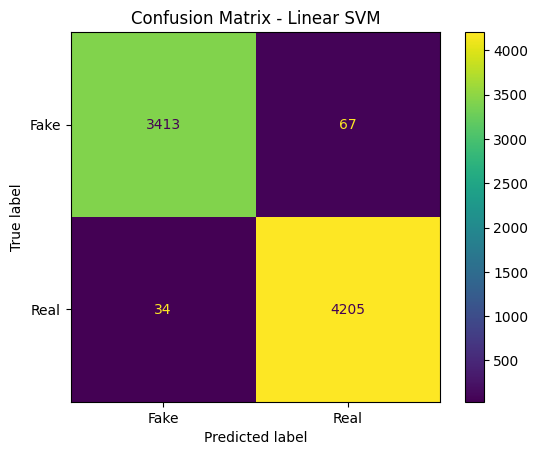

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()

Out of 7,719 test articles:

- 3,413 Fake articles were correctly classified as Fake.
- 4,205 Real articles were correctly classified as Real.
- 67 Fake articles were incorrectly classified as Real.
- 34 Real articles were incorrectly classified as Fake.

Overall, the model correctly classified 7,618 articles and misclassified 101.

Although the error rate is low, Fake articles being classified as Real are particularly relevant in the context of fake-news detection. These errors will therefore be examined more closely in the following error analysis.

## 3.7 Error Analysis

Although the final Linear SVM achieves strong overall performance, it still misclassifies 101 of the 7,719 test articles.

To better understand the model's limitations, the misclassified articles are examined together with their true labels, predicted labels, and SVM decision scores.

This analysis is only descriptive only.

In [38]:
results = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

results.head()

,text,true_label,predicted_label
0,"hillary clinton, currently leading the race to...",0,0
1,it s no secret that donald trump courts white ...,0,0
2,"singapore nato’s top military officer, general...",1,1
3,honolulu one of three federal appeals court ju...,1,1
4,"by now, everyone is aware of the appallingly a...",0,0


In [39]:
results["decision_score"] = best_model.decision_function(X_test)

In [40]:
results[
    ["true_label", "predicted_label", "decision_score"]
].head()

,true_label,predicted_label,decision_score
0,0,0,-2.323691
1,0,0,-1.707820
2,1,1,2.138831
3,1,1,1.553539
4,0,0,-3.373160


In [41]:
errors = results[
    results["true_label"] != results["predicted_label"]
].copy()

print("Number of errors:", len(errors))

Number of errors: 101


In [42]:
label_names = {
    0: "Fake",
    1: "Real"
}

errors["true_class"] = errors["true_label"].map(label_names)
errors["predicted_class"] = errors["predicted_label"].map(label_names)

In [43]:
errors[
    ["text", "true_class", "predicted_class", "decision_score"]
].head(10)

,text,true_class,predicted_class,decision_score
21,president-elect donald trump said thursday it ...,Fake,Real,0.038236
48,a caucus formed by politico consisting of oper...,Fake,Real,0.022234
161,paul ryan has had almost 8 years to lead the c...,Fake,Real,0.013967
240,"on friday, democrats were doing their best to ...",Fake,Real,0.219695
259,the white house confirmed to fox business that...,Fake,Real,0.408804
329,"killing each other is okay, it s when a cop ki...",Fake,Real,0.235316
493,philadelphia democrats divided over the future...,Real,Fake,-0.183700
517,"during obama s 8 years in office, he took a pa...",Fake,Real,0.390260
554,"turnberry, scotland donald trump flew all nigh...",Real,Fake,-0.038029
561,the last time a pope got involved in politics ...,Fake,Real,0.215167


In [44]:
fake_as_real = errors[
    (errors["true_label"] == 0) &
    (errors["predicted_label"] == 1)
]

real_as_fake = errors[
    (errors["true_label"] == 1) &
    (errors["predicted_label"] == 0)
]

print("Fake predicted as Real:", len(fake_as_real))
print("Real predicted as Fake:", len(real_as_fake))

Fake predicted as Real: 67
Real predicted as Fake: 34


In [47]:
pd.set_option("display.max_colwidth", None)

In [48]:
fake_as_real[
    ["text", "decision_score"]
].sort_values(
    "decision_score",
    ascending=False
).head(10)

,text,decision_score
6950,"the washington post nearly a third of territory reclaimed from the islamic state in iraq and syria since 2014 has been won in the past six months, due to new policies adopted by the trump administration, a senior state department official said friday.brett mcgurk, the state department s senior envoy to the anti-islamic state coalition, said that steps president trump has taken, including delegating decision-making authority down from the white house to commanders in the field, have dramatically accelerated gains against the militants.combined islamic state losses in both countries since the group s peak control in early 2015 total about 27,000 square miles of territory 78 percent of militant holdings in iraq and 58 percent in syria. about 8,000 square miles have been reclaimed under trump, mcgurk said in a briefing for reporters.although the trump administration has yet to announce its new strategy for the campaign against the islamic state, mcgurk cited key changes under trump. in addition to the delegation of decision-making authority, which he said has allowed much greater responsiveness to opportunities and changing circumstances, he cited a campaign of annihilation that has concentrated on surrounding cities held by the militants before launching offensives, to ensure that no militants will escape.he said the 2,000 militants remaining in raqqa most likely will die in raqqa. the united nations has estimated that 25,000 civilians also remain in the city.mcgurk, who held the same job in the obama administration, also cited renewed administration efforts to increase burden sharing from the coalition among what he said were 73 countries. most of them do not contribute to the warfighting but are expected to help with stabilization efforts in cleared areas, including in the iraqi city of mosul, where u.s.-backed iraq security forces declared victory over the islamic state last month.",1.935170
4035,"u.s. immigration and customs enforcement said tuesday that a somali refugee charged with ramming his car into a canadian policeman, stabbing him and then injuring four people while leading officers on a high-speed chase over the weekend was ordered deported from the u.s. in 2011.jennifer elzea, an ice spokeswoman, said hasan sharif abdulahi was taken into ice s custody in san diego in july of that year and in september an immigration judge ordered him sent back to somalia.elzea said sharif was released from custody two months later then failed to report as ordered for his removal on jan. 24, 2012. she said efforts to locate him were unsuccessful.sharif faces 11 charges, including five of attempted murder in the saturday night attack in edmonton, alberta. police have raised the possibility of filing terrorism charges against sharif because there was an islamic state flag in his car and he was investigated in 2015 for espousing extremist views.canadian public safety minister ralph goodale said sharif, 30, entered canada legally in 2012 and obtained refugee status.a preliminary hearing for sharif opened tuesday but was recessed so he can find a lawyer. he appeared on closed-circuit television and followed proceedings with the help of an interpreter. the suspect spoke briefly with a lawyer who stepped forward to help.edmonton police say they believe sharif acted alone during the series of attacks, which began around 8:15 p.m. saturday as police constable mike chernyk was handling crowd control outside a canadian football league game at a stadium just northeast of downtown. ap",1.213402
7171,"how about america calls him out for arming isis with our tax dollars? russian president vladimir putin on sunday branded u.s. support for rebel forces in syria as illegal and ineffective, saying u.s.-trained rebels were leaving to join islamic state with weapons supplied by washington.in an interview with u.s. networks recorded ahead of a meeting with u.s. president barack obama, putin said syrian president bashar al-assad 

In [49]:
real_as_fake[
    ["text", "decision_score"]
].sort_values(
    "decision_score",
    ascending=True
).head(10)

text  \
7652  washington president barack obama on sunday said americans would stand united and “not give in to fear or turn against each other” in the wake of a nightclub shooting in orlando, florida, that killed 50 people. following is the full text of remarks, obama delivered at the white house: today, as americans, we grieve the brutal murder - a horrific massacre - of dozens of innocent people. we pray for their families, who are grasping for answers with broken hearts. we stand with the people of orlando, who have endured a terrible attack on their city. although it’s still early in the investigation, we know enough to say that this was an act of terror and an act of hate. and as americans, we are united in grief, in outrage, and in resolve to defend our people. i just finished a meeting with fbi director comey and my homeland security and national security advisers. the fbi is on the scene and leading the investigation, in partnership with local law enforcement. i’ve directed that the full resources of the federal government be made available for this investigation. we are still learning all the facts. this is an open investigation. we’ve reached no definitive judgment on the precise motivations of the killer. the fbi is appropriately investigating this as an act of terrorism. and i’ve directed that we must spare no effort to determine what - if any - inspiration or association this killer may have had with terrorist groups. what is clear is that he was a person filled with hatred. over the coming days, we’ll uncover why and how this happened, and we will go wherever the facts lead us. this morning i spoke with my good friend, orlando mayor buddy dyer, and i conveyed the condolences of the entire american people. this could have been any one of our communities. so i told mayor dyer that whatever help he and the people of orlando need - they are going to get it. as a country, we will be there for the people of orlando today, tomorrow and for all the days to come. we also express our profound gratitude to all the police and first responders who rushed into harm’s way. their courage and professionalism saved lives, and kept the carnage from being even worse. it’s the kind of sacrifice that our law enforcement professionals make every single day for all of us, and we can never thank them enough. this is an especially heartbreaking day for all our friends - our fellow americans - who are lesbian, gay, bisexual or transgender. the shooter targeted a nightclub where people came together to be with friends, to dance and to sing, and to live. the place where they were attacked is more than a nightclub - it is a place of solidarity and empowerment where people have come together to raise awareness, to speak their minds, and to advocate for their civil rights. so this is a sobering reminder that attacks on any american - regardless of race, ethnicity, religion or sexual orientation - is an attack on all of us and on the fundamental values of equality and dignity that define us as a country. and no act of hate or terror will ever change who we are or the values that make us americans. today marks the most deadly shooting in american history. the shooter was apparently armed with a handgun and a powerful assault rifle. this massacre is therefore a further reminder of how easy it is for someone to get their hands on a weapon that lets them shoot people in a school, or in a house of worship, or a movie theater, or in a nightclub. and we have to decide if that’s the kind of country we want to be. and to actively do nothing is a decision as well. in the coming hours and days, we’ll learn about the victims of this tragedy. their names. their faces. who they were. the joy that they brought to families and to friends, and the difference that they made in this world. say a prayer for them and say a prayer for their families - that god give them the strength to bear the unbearable. and that he give us all the strength to be there for them, a

In [50]:
tfidf = best_model.named_steps["tfidf"]
svm = best_model.named_steps["model"]

feature_names = tfidf.get_feature_names_out()
coefficients = svm.coef_[0]

print("Features:", len(feature_names))
print("Coefficients:", len(coefficients))

Features: 33352
Coefficients: 33352


In [51]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

fake_features = (
    coef_df
    .sort_values("coefficient")
    .head(30)
)

real_features = (
    coef_df
    .sort_values("coefficient", ascending=False)
    .head(30)
)

In [52]:
print("Features most associated with FAKE:")
display(fake_features)

print("\nFeatures most associated with REAL:")
display(real_features)

Features most associated with FAKE:


,feature,coefficient
31975,via,-9.489872
24383,read,-4.800626
13372,gop,-3.293852
20017,mr,-3.181642
30050,this,-2.971300
31680,us,-2.960084
26810,sen,-2.863321
6632,com,-2.712567
16799,just,-2.699060
25093,rep,-2.559631



Features most associated with REAL:


,feature,coefficient
26168,said,7.873662
32399,washington,4.388581
21206,on,4.053960
20830,nov,3.056574
32518,wednesday,2.700586
30145,thursday,2.474454
25184,republican,2.417928
30842,tuesday,2.324015
30292,told,2.155004
6703,comment,1.949174


In [53]:
errors["abs_decision_score"] = errors["decision_score"].abs()

errors["abs_decision_score"].describe()

count    101.000000
mean       0.311885
std        0.353211
min        0.008311
25%        0.082063
50%        0.220168
75%        0.401266
max        2.113134
Name: abs_decision_score, dtype: float64

In [54]:
for threshold in [0.1, 0.25, 0.5, 1.0]:
    count = (errors["abs_decision_score"] < threshold).sum()
    pct = count / len(errors) * 100

    print(
        f"|decision score| < {threshold}: "
        f"{count} errors ({pct:.1f}%)"
    )

|decision score| < 0.1: 27 errors (26.7%)
|decision score| < 0.25: 59 errors (58.4%)
|decision score| < 0.5: 85 errors (84.2%)
|decision score| < 1.0: 95 errors (94.1%)


## Error Analysis Summary

The final Linear SVM misclassified 101 out of 7,719 test articles: 67 Fake articles were predicted as Real and 34 Real articles were predicted as Fake.

### Decision Scores

Analysis of the SVM decision scores shows that most misclassifications occur relatively close to the decision boundary:

- 26.7% of errors have an absolute decision score below 0.10.
- 58.4% are below 0.25.
- 84.2% are below 0.50.
- 94.1% are below 1.00.

Only 6 of the 101 misclassified articles have an absolute decision score greater than or equal to 1, indicating that strongly incorrect decisions are relatively uncommon.

### Feature Analysis

Inspection of the Linear SVM coefficients reveals strong lexical differences between the two classes.

Features strongly associated with the Fake class include terms such as `via`, `read`, `watch`, `pic`, `flickr`, `wfb`, and `breitbart`. Several of these appear to reflect publishing conventions, source attribution, or web-related artifacts rather than the factual content of an article.

Conversely, features strongly associated with the Real class include `said`, `washington`, `told`, `reporters`, weekday names, `EDT`, `EST`, and geographical datelines such as `london` and `berlin`. These are characteristic of conventional news-agency writing.

Although explicit source markers such as `Reuters` were removed during preprocessing, the model can therefore still exploit indirect stylistic and editorial patterns associated with the underlying sources.

### Interpretation

The error analysis suggests that the classifier learns both linguistic content and source-specific stylistic patterns. Some Fake articles misclassified as Real closely resemble conventional news reporting, while some Real articles misclassified as Fake have less typical structures, including speeches, letters, or other forms of long quoted material.

Consequently, the approximately 98.7% test F1-macro should be interpreted as strong performance on the ISOT dataset rather than evidence that the model can identify the factual truth of arbitrary news articles with equivalent accuracy.

These findings highlight a key limitation of source-dependent fake-news datasets: high in-distribution classification performance may partly reflect differences in writing style and publication conventions between the classes.

## 3.8 Model Persistence

The final TF-IDF + Linear SVM pipeline is saved as a single serialized object for later inference.

In [58]:
import joblib
import numpy as np

In [56]:
MODEL_PATH = "../models/linear_svm_tfidf.joblib"

joblib.dump(best_model, MODEL_PATH)

['../models/linear_svm_tfidf.joblib']

In [59]:
loaded_model = joblib.load(MODEL_PATH)

loaded_predictions = loaded_model.predict(X_test)

print(
    "Predictions identical:",
    np.array_equal(y_pred, loaded_predictions)
)

Predictions identical: True
